# BLUF

In [22]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os
import re

# Machine Learning Imports
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer


SETUP AND DATA EXPLORATION

In [2]:
#Load the dataset
df = pd.read_csv('food_delivery_analytics_cleaned.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   order_id                           15000 non-null  object 
 1   city_tier                          15000 non-null  int64  
 2   customer_age                       15000 non-null  int64  
 3   customer_loyalty_score             15000 non-null  float64
 4   order_hour                         15000 non-null  int64  
 5   order_day_of_week                  15000 non-null  int64  
 6   order_month                        15000 non-null  int64  
 7   delivery_distance_km               15000 non-null  float64
 8   preparation_time_minutes           15000 non-null  int64  
 9   delivery_time_minutes              15000 non-null  int64  
 10  estimated_delivery_time            15000 non-null  int64  
 11  traffic_level_score                15000 non-null  flo

In [3]:
df.head()

,order_id,city_tier,customer_age,customer_loyalty_score,order_hour,order_day_of_week,order_month,delivery_distance_km,preparation_time_minutes,delivery_time_minutes,...,final_amount_paid,number_of_items,cancellation_flag,delayed_delivery_flag,refund_flag,promo_code_used,premium_customer_flag,festival_or_weekend_flag,delivery_partner_experience_years,delivery_efficiency_score
0,5a87c6ab-e4a8-44ef-8852-f7a63e3b3943,2,21,4.957522,20,6,6,14.117144,23,76,...,111.563784,4,False,False,True,False,False,True,9,71.1
1,8eab78a5-a5c5-41d7-9a5f-5779ee5f2d3d,1,63,38.744721,0,2,2,9.177354,16,34,...,116.059264,7,False,False,False,True,False,False,12,100.0
2,1338cc5b-e5cf-419f-a7c9-4a2577608715,1,68,45.170997,9,2,11,34.753921,41,152,...,111.708170,12,False,False,False,False,False,False,10,34.4
3,5277f2fb-b1b3-4f58-9975-12f8f1b71421,2,30,10.573003,6,6,5,26.596184,9,93,...,153.301345,7,False,False,False,False,True,True,1,45.0
4,df159a97-3a78-4b08-a524-ec433c75b670,2,60,58.284620,12,1,9,26.204152,49,141,...,111.128807,2,True,False,False,False,False,False,6,25.1


In [4]:
df.describe()

,city_tier,customer_age,customer_loyalty_score,order_hour,order_day_of_week,order_month,delivery_distance_km,preparation_time_minutes,delivery_time_minutes,estimated_delivery_time,...,delivery_partner_rating,customer_rating,order_value,delivery_fee,discount_amount,tip_amount,final_amount_paid,number_of_items,delivery_partner_experience_years,delivery_efficiency_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,...,14850.000000,14850.000000,15000.000000,15000.000000,15000.000000,14850.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,2.253133,46.569667,50.017658,11.470933,3.141933,6.474667,20.133756,32.749667,94.139267,94.140667,...,4.196121,3.993556,113.954265,7.493531,14.932581,12.569739,119.083685,6.489933,8.047600,59.165933
std,0.827951,16.840706,28.771665,6.946134,1.809864,3.454469,11.543488,16.162719,33.597132,32.490455,...,0.391959,0.535016,22.713411,4.352771,8.706253,7.221087,25.798587,3.438123,4.302995,18.102487
min,1.000000,18.000000,0.007172,0.000000,1.000000,1.000000,0.103086,5.000000,10.000000,11.000000,...,2.700000,1.500000,100.000000,0.000432,0.000788,0.000205,72.395550,1.000000,1.000000,1.900000
25%,2.000000,32.000000,25.199828,5.000000,1.000000,3.000000,10.133190,19.000000,68.000000,69.000000,...,3.900000,3.600000,100.000000,3.704018,7.279980,6.396828,101.152407,4.000000,4.000000,46.400000
50%,3.000000,46.000000,50.092268,11.000000,3.000000,7.000000,20.228709,33.000000,95.000000,94.000000,...,4.200000,4.000000,100.000000,7.458605,14.857607,12.629302,113.039544,7.000000,8.000000,59.100000
75%,3.000000,61.000000,74.840432,18.000000,5.000000,9.000000,30.047891,47.000000,120.000000,119.000000,...,4.500000,4.400000,124.153105,11.278689,22.521458,18.848336,130.541371,9.000000,12.000000,72.000000
max,3.000000,75.000000,99.989375,23.000000,6.000000,12.000000,39.998739,60.000000,180.000000,178.000000,...,5.000000,5.000000,215.614574,14.998370,29.999893,24.998828,238.600286,12.000000,15.000000,100.000000


In [5]:
#Check for null values
df.isnull().sum()

order_id                               0
city_tier                              0
customer_age                           0
customer_loyalty_score                 0
order_hour                             0
order_day_of_week                      0
order_month                            0
delivery_distance_km                   0
preparation_time_minutes               0
delivery_time_minutes                  0
estimated_delivery_time                0
traffic_level_score                    0
weather_severity_score                 0
restaurant_rating                      0
delivery_partner_rating              150
customer_rating                      150
order_value                            0
delivery_fee                           0
discount_amount                        0
tip_amount                           150
final_amount_paid                      0
number_of_items                        0
cancellation_flag                      0
delayed_delivery_flag                  0
refund_flag     

In [6]:
#Checking relevant features
df['city_tier'].value_counts()

city_tier
3    7520
2    3757
1    3723
Name: count, dtype: int64

In [7]:
df['delivery_time_minutes'].value_counts()

delivery_time_minutes
106    184
100    171
64     168
101    168
113    168
      ... 
179      3
172      3
11       2
178      1
175      1
Name: count, Length: 171, dtype: int64

In [8]:
df['traffic_level_score'].value_counts()

traffic_level_score
1.0     1594
1.4      182
4.6      182
6.1      181
9.3      175
        ... 
1.5      130
5.9      129
6.2      127
6.4      123
10.0      85
Name: count, Length: 91, dtype: int64

In [9]:
df['weather_severity_score'].value_counts()


weather_severity_score
8.9     186
8.8     173
3.5     173
5.0     169
0.5     168
       ... 
6.0     130
6.2     127
9.2     125
10.0     70
0.0      66
Name: count, Length: 101, dtype: int64

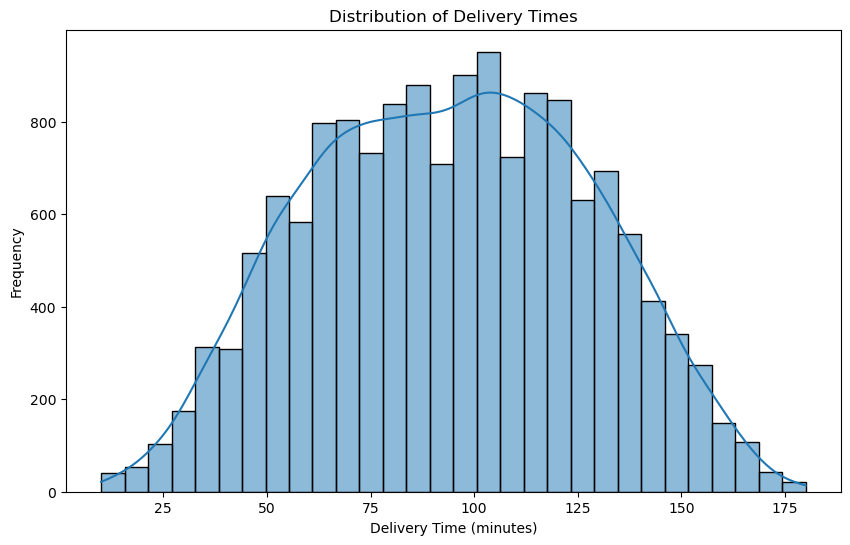

In [11]:
#Distribution of delivery times
plt.figure(figsize=(10, 6))
sns.histplot(df['delivery_time_minutes'], bins=30, kde=True)
plt.title('Distribution of Delivery Times')
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Frequency')
plt.show()


In [12]:
# Create late label (SLA Threshold > 120 mins)
df['is_late'] = (df['delivery_time_minutes'] > 120).astype(int)

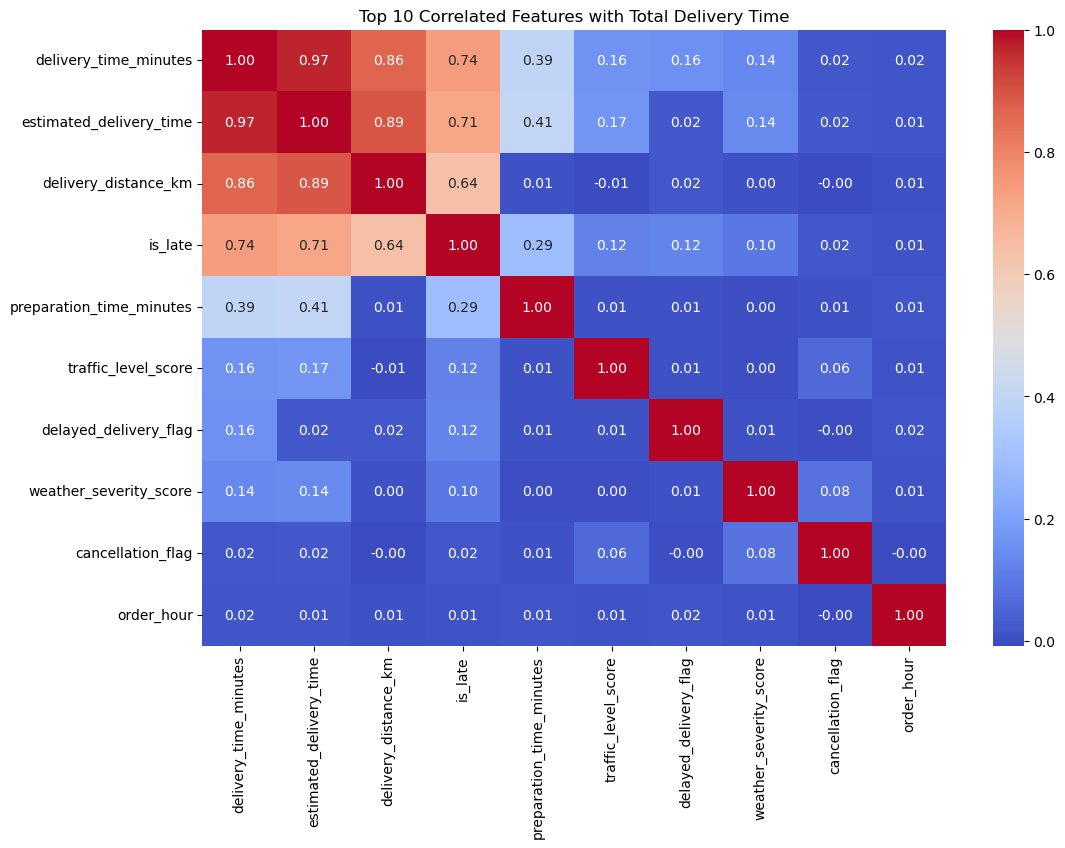

In [14]:
#Correlation heatmap
plt.figure(figsize=(12, 8))
numeric_cols = df.select_dtypes(include=['number', 'bool']).columns
corr_matrix = df[numeric_cols].corr()

#Top 10 features correlated with delivery time
top_features = corr_matrix['delivery_time_minutes'].sort_values(ascending=False).index[:10]
sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Top 10 Correlated Features with Total Delivery Time')
plt.show()

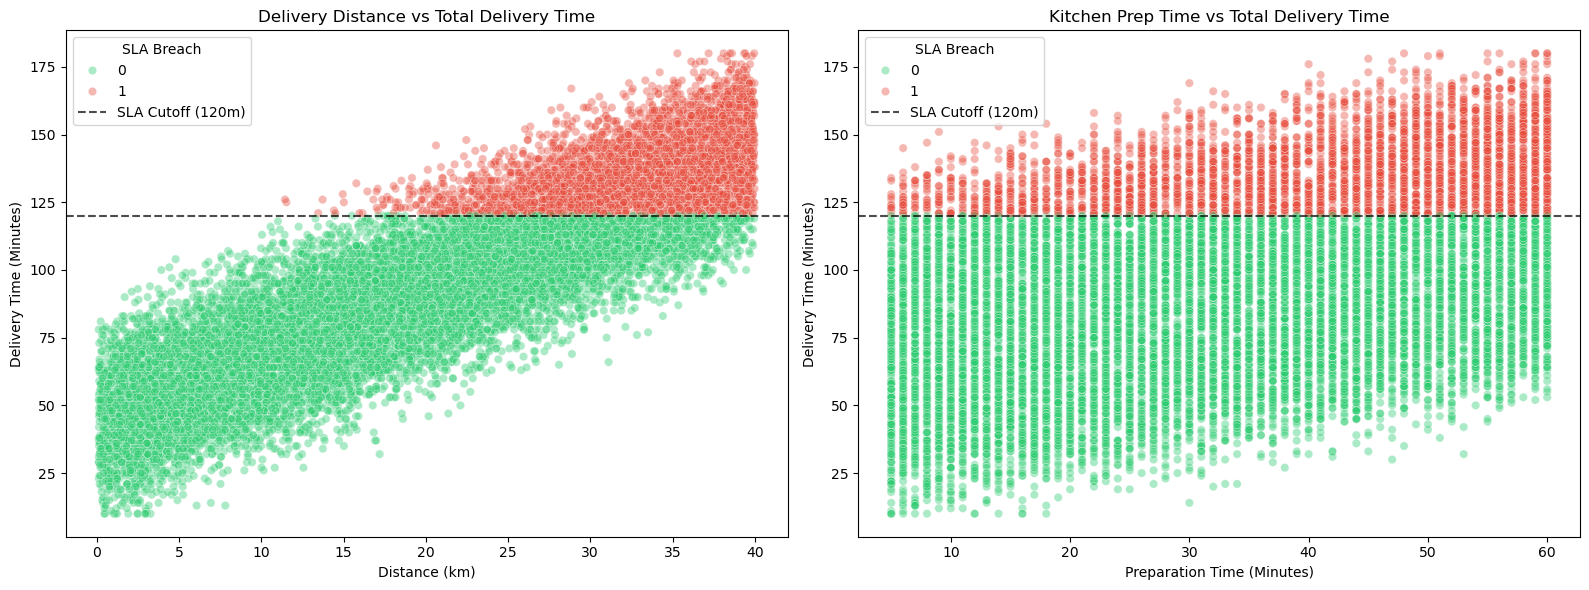

In [ ]:
#Plotting key relationships

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distance vs Delivery Time
sns.scatterplot(data=df, x='delivery_distance_km', y='delivery_time_minutes', 
                hue='is_late', palette={0: '#2ecc71', 1: '#e74c3c'}, alpha=0.4, ax=axes[0])
axes[0].axhline(120, color='black', linestyle='--', alpha=0.7, label='SLA Cutoff (120m)')
axes[0].set_title('Delivery Distance vs Total Delivery Time')
axes[0].set_xlabel('Distance (km)')
axes[0].set_ylabel('Delivery Time (Minutes)')
axes[0].legend(title='SLA Breach')

# Prep Time vs Delivery Time
sns.scatterplot(data=df, x='preparation_time_minutes', y='delivery_time_minutes', 
                hue='is_late', palette={0: '#2ecc71', 1: '#e74c3c'}, alpha=0.4, ax=axes[1])
axes[1].axhline(120, color='black', linestyle='--', alpha=0.7, label='SLA Cutoff (120m)')
axes[1].set_title('Kitchen Prep Time vs Total Delivery Time')
axes[1].set_xlabel('Preparation Time (Minutes)')
axes[1].set_ylabel('Delivery Time (Minutes)')
axes[1].legend(title='SLA Breach')

plt.tight_layout()
plt.show()

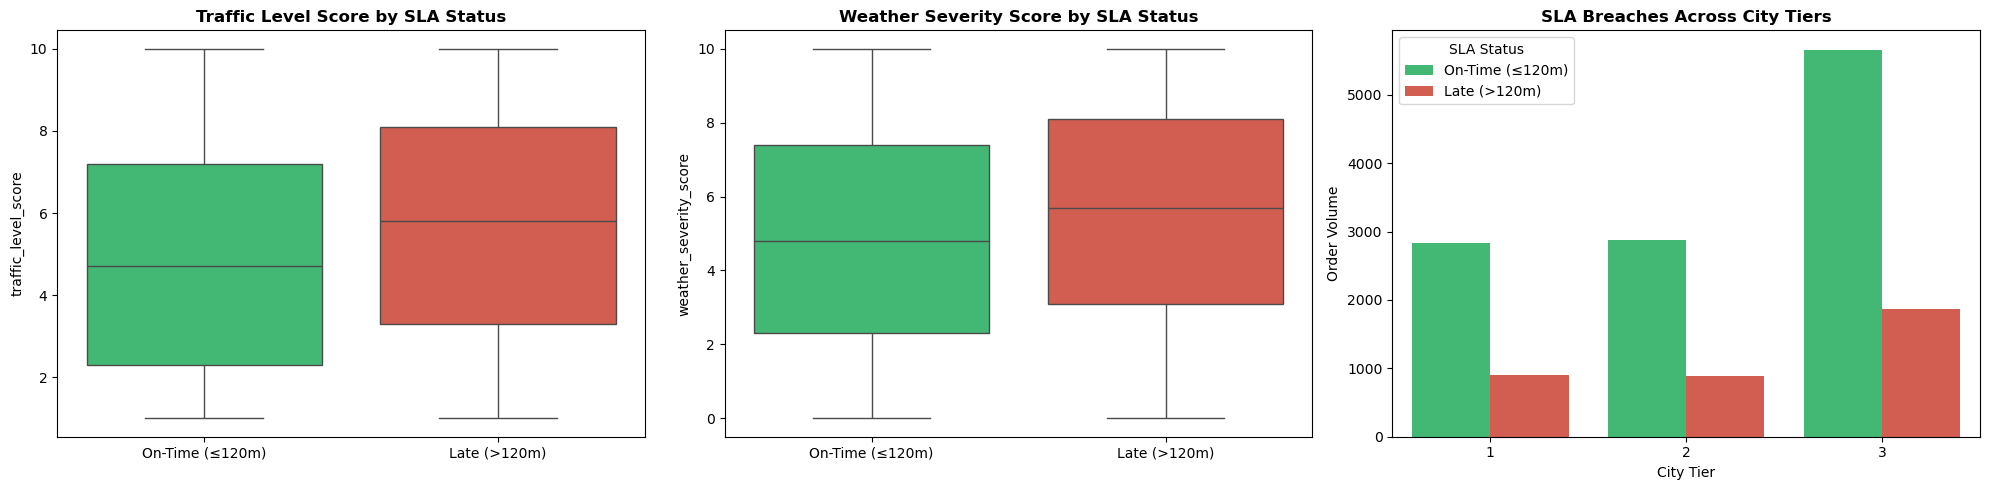

In [ ]:
#Plotting SLA breaches by traffic, weather, and city tier

# Create a string column for visualization 
df['SLA_Status'] = np.where(df['delivery_time_minutes'] > 120, 'Late (>120m)', 'On-Time (≤120m)')

# Define the color palette
status_palette = {
    'On-Time (≤120m)': '#2ecc71',  # Green
    'Late (>120m)': '#e74c3c'      # Red
}

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Traffic Score Distributions 
sns.boxplot(data=df, x='SLA_Status', y='traffic_level_score', hue='SLA_Status', palette=status_palette, ax=axes[0], legend=False)
axes[0].set_title('Traffic Level Score by SLA Status', fontweight='bold')
axes[0].set_xlabel('')

# Weather Severity Distributions
sns.boxplot(data=df, x='SLA_Status', y='weather_severity_score', hue='SLA_Status', palette=status_palette, ax=axes[1], legend=False)
axes[1].set_title('Weather Severity Score by SLA Status', fontweight='bold')
axes[1].set_xlabel('')

# City Tier Volumes vs Breaches
sns.countplot(data=df, x='city_tier', hue='SLA_Status', palette=status_palette, ax=axes[2])
axes[2].set_title('SLA Breaches Across City Tiers', fontweight='bold')
axes[2].set_xlabel('City Tier')
axes[2].set_ylabel('Order Volume')
axes[2].legend(title='SLA Status')

plt.tight_layout()
plt.show()

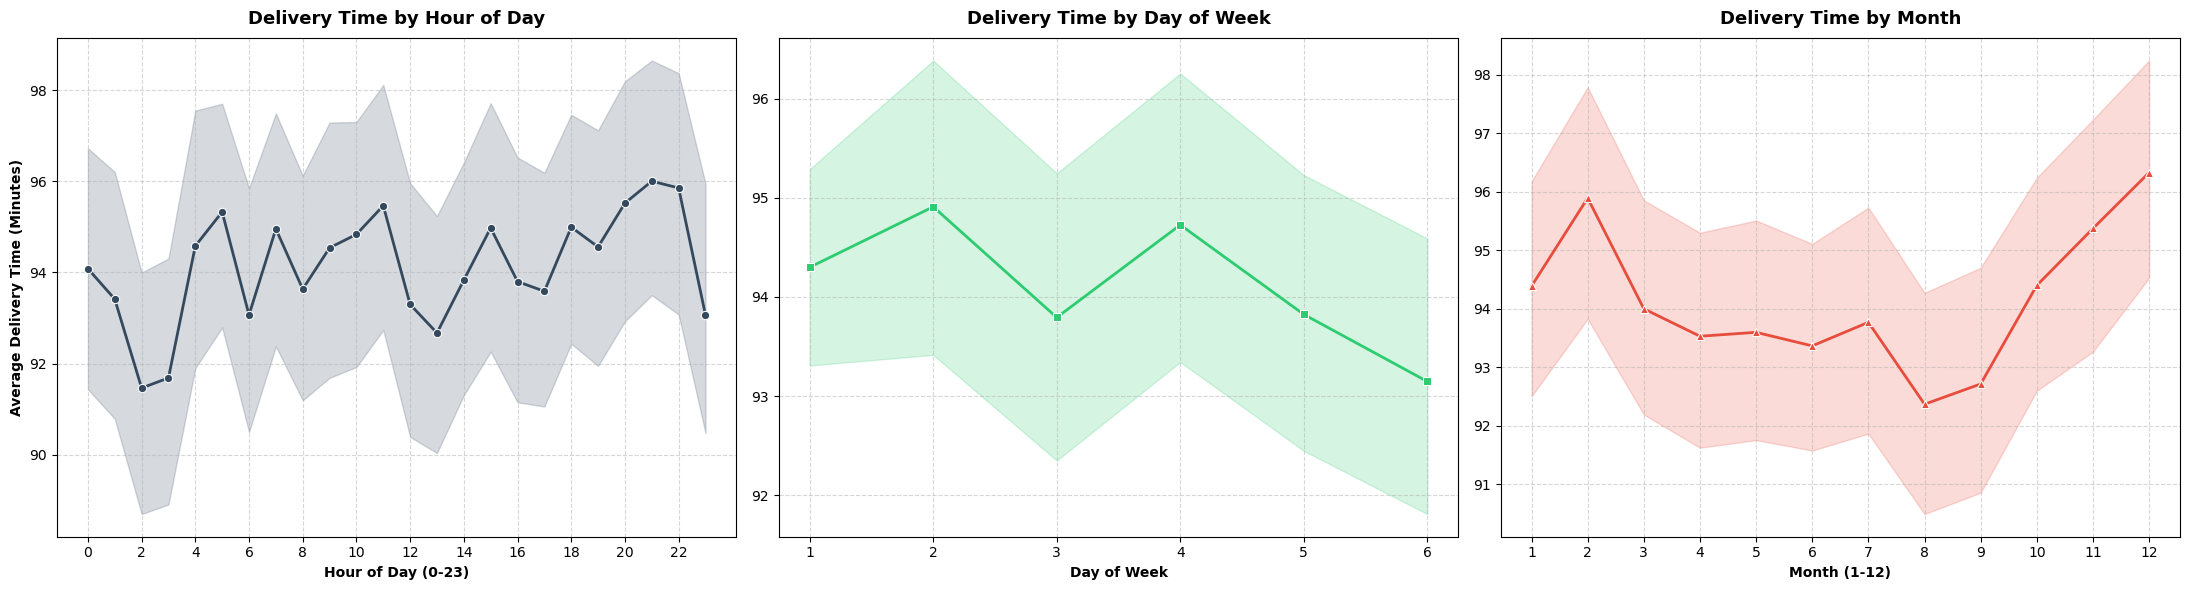

In [ ]:
#Plotting temporal trends in delivery times by hour, day of week, and month

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Hour of Day vs Delivery Time
sns.lineplot(data=df, x='order_hour', y='delivery_time_minutes', marker='o', color='#34495e', linewidth=2, ax=axes[0])
axes[0].set_title('Delivery Time by Hour of Day', fontsize=13, fontweight='bold', pad=10)
axes[0].set_xlabel('Hour of Day (0-23)', fontweight='bold')
axes[0].set_ylabel('Average Delivery Time (Minutes)', fontweight='bold')
axes[0].set_xticks(range(0, 24, 2))  
axes[0].grid(True, linestyle='--', alpha=0.5)

# Day of the Week vs Delivery Time
sns.lineplot(data=df, x='order_day_of_week', y='delivery_time_minutes', marker='s', color='#2ecc71', linewidth=2, ax=axes[1])
axes[1].set_title('Delivery Time by Day of Week', fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel('Day of Week', fontweight='bold')
axes[1].set_ylabel('')  
axes[1].grid(True, linestyle='--', alpha=0.5)

# 3. Month of the Year vs Delivery Time
sns.lineplot(data=df, x='order_month', y='delivery_time_minutes', marker='^', color='#e74c3c', linewidth=2, ax=axes[2])
axes[2].set_title('Delivery Time by Month', fontsize=13, fontweight='bold', pad=10)
axes[2].set_xlabel('Month (1-12)', fontweight='bold')
axes[2].set_ylabel('')
axes[2].set_xticks(range(1, 13))  
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

DATA PREPROCESSING

In [ ]:
#Split data into features and target

In [ ]:
#Drop unnecessary columns

In [ ]:
#Assess Missing Values


In [ ]:
#Data already cleaned
#Feature engineering, etc

MODEL BUILDING

In [ ]:
#3 diff models

WATERFALL EVALUATION (EDIT NAME)

ANALYSIS